# 05 - MARL (MAPPO) Analysis

Loads the MAPPO training histories (`results/mappo/training_history_seed*.json`) saved during `scripts/train_mappo.py`. Architecture and credit-assignment justification: `docs/marl_design.md`. A real PPO log-probability bug was found and fixed during development -- see `docs/experiment_log.md` for the full diagnosis.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))
RESULTS = REPO_ROOT / "results"
DOCS = REPO_ROOT / "docs"
DATA = REPO_ROOT / "data" / "processed"


## Training convergence, all 3 seeds

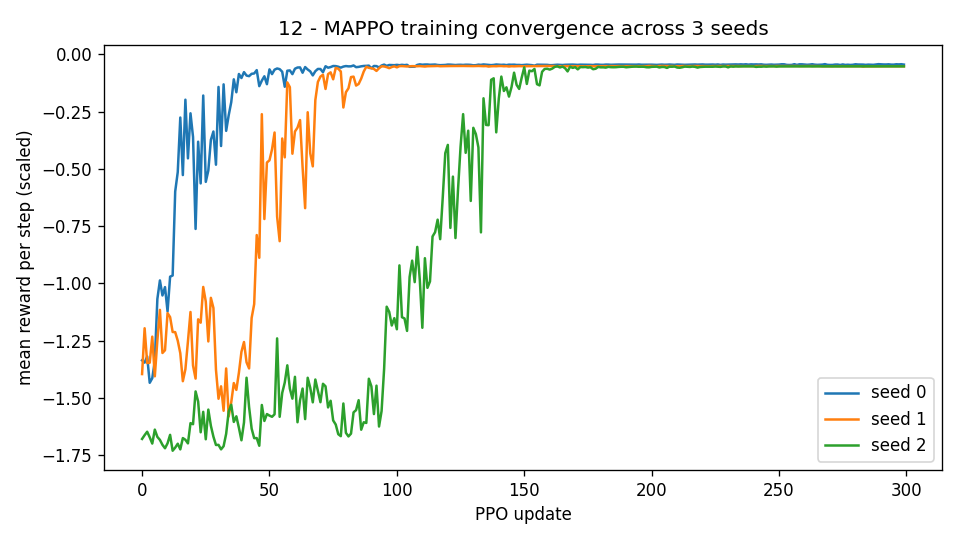

In [2]:
display(Image(filename=str(RESULTS / 'figures' / '12_reward_convergence.png')))

## Seed-to-seed variability, PPO vs. MAPPO

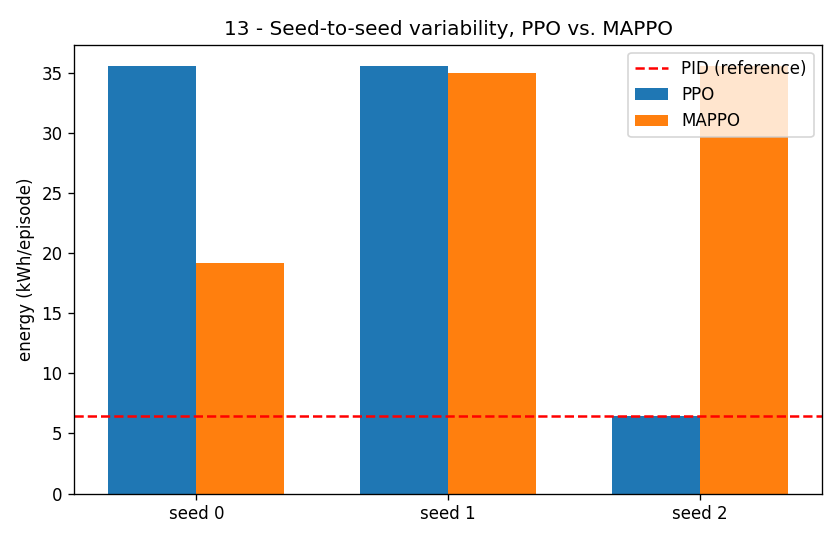

In [3]:
display(Image(filename=str(RESULTS / 'figures' / '13_seed_variability.png')))

## Ablations: forecast usage and safety-shield reliance

In [4]:
pd.read_csv(RESULTS / 'tables' / '07_ablation_results.csv')

,ablation,energy_kwh,violation_pct
0,forecast: with,19.153132,NaN
1,forecast: without,19.157554,NaN
2,safety shield: on,19.153132,0.0
3,safety shield: off,19.153132,0.0


**Shield ablation, post-fix**: shield-on and shield-off produce *identical* results for the (bug-fixed) MAPPO seed-0 policy (19.15 kWh, 0% violations both ways) -- confirming the policy is genuinely safe on its own, not shield-dependent. This was explicitly **not** true before the PPO log-probability bug fix (`docs/experiment_log.md`).

## Seed-level numeric results

In [5]:
pd.read_csv(RESULTS / 'tables' / '06_seed_level_rl_results.csv')

,algorithm,seed,energy_kwh_mean,violation_pct,max_temp_c
0,ppo,0,35.550000,0.0,23.981045
1,ppo,1,35.550000,0.0,23.981045
2,ppo,2,6.472092,0.0,25.845779
3,mappo,0,19.153132,0.0,23.981045
4,mappo,1,34.950985,0.0,23.981045
5,mappo,2,35.550000,0.0,23.981045
